# S&P 500 multivariate forecasting 

Faster sibling of `01_sp500_multivariate_backtest.ipynb`: same structure and
same `DataService`, but **YAML-driven settings** in
``specs/sp500_backtest_smoke.yaml`` are tuned so a full Run All
finishes in **under one minute** on a laptop (cached parquet + a handful of
forecast origins + fast models only). Use the main notebook + full YAML for the
actual backtests and slides.

**What you get in this notebook**

1. A compact **observed-history** figure for the target log return (context for the score).
2. A plain-text **`describe_spec()`** summary of the active `BacktestSpec` (the
   Canada food CPI notebook prints YAML-backed specs the same way).
3. A unified **`RESULTS_DF`** leaderboard: mean CRPS in **log-return** space and
   mean CRPS on **realised same-day open (USD)** (pushing each log-return quantile
   through `prior_adj_close * exp(q)`), plus covariate usage and **direction**
   metrics (point sign vs realised sign; ROC on `prob_up` from quantiles).
4. A **formatted table** plus **mean CRPS bar charts** (log return and open level)
   for slides.
5. One **open-price** figure: realised open vs median-implied open for **every**
   enabled model that completes (per-model 5–95% bands when available), on the
   scored backtest dates.

---

**How to run:** edit **`specs/sp500_backtest_smoke.yaml`**, then **Run All**.  The
multivariate README documents prerequisites and the no-leakage contract. **`specs/sp500_backtest_smoke.yaml`** is used for showcasing the experiment quickly.


---
## 1. Setup

Heavy lifting lives in Python modules next to this notebook:

- `specs/sp500_backtest_smoke.yaml` — backtest task/window, model toggles, lags, covariates.
- `backtest_grid.py` — grid of `backtest` runs, open-level CRPS, direction metrics.
- `data.py` — `build_sp500_multivariate_service()`, covariate series ids, lagging policy.
- `plots.py` — matplotlib figures (target history, CRPS bars).
- `analysis.py` — `style_results_dataframe()` for readable leaderboards.

Predictors are imported from `aieng.forecasting.methods` (re-exports
`DartsLinearRegressionPredictor`, `DartsLightGBMPredictor`, and
`DartsAutoARIMAPredictor`).




---
## 2. Configuration (YAML + loader cell)

All experiment parameters live in **`specs/sp500_backtest_smoke.yaml`**
(next to this notebook): `backtest` (task + evaluation window + warmup) and
`experiment` (data cache window, which models to run, lags, covariate subset,
LightGBM thread kwargs). 

`backtest.start` / `backtest.end` are **forecast origins** (`as_of`): one full
backtest fit per business day in that inclusive range. For `horizons: [1]` and
`frequency: B`, each scored prediction’s `forecast_date` is the **next** business
session after `as_of` (see `describe_spec` output).

`experiment.data_history_start` should be **well before** your first origin so
lag features and covariates look like production. `backtest.warmup` is the
minimum **rows of target** required at each origin; use at least ~one trading
year (~252) for a realistic floor in heavier runs, not just the lag length.



In [1]:
from __future__ import annotations

import yaml


EXPERIMENT_CONFIG_PATH = "./specs/sp500_backtest_smoke.yaml"

with open(EXPERIMENT_CONFIG_PATH, encoding="utf-8") as f:
    EXPERIMENT_CFG = yaml.safe_load(f)

_bt = EXPERIMENT_CFG["backtest"]
_ex = EXPERIMENT_CFG["experiment"]

RUN_MODELS = dict(_ex["run_models"])
SPEC_START = _bt["start"]
SPEC_END = _bt["end"]
SPEC_STRIDE = int(_bt["stride"])
SPEC_WARMUP = int(_bt["warmup"])
DATA_HISTORY_START = _ex["data_history_start"]
REFRESH_CACHE = bool(_ex["refresh_cache"])
LAGS = int(_ex["lags"])
LAGS_PAST_COVARIATES = int(_ex["lags_past_covariates"])
NUM_SAMPLES = int(_ex["num_samples"])
FAST_COVARIATE_SERIES_IDS = list(_ex["fast_covariate_series_ids"])
LIGHTGBM_KWARGS = dict(_ex["lightgbm_kwargs"])

print(f"Loaded experiment config: {EXPERIMENT_CONFIG_PATH}")

Loaded experiment config: ./specs/sp500_backtest_smoke.yaml


---
## 3. Imports



In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd


warnings.filterwarnings("ignore")

from aieng.forecasting.evaluation import (
    BacktestSpec,
    describe_spec,
)
from sp500_forecasting import (
    DEFAULT_COVARIATE_SERIES_IDS,
    SP500_TICKER,
    build_sp500_multivariate_service,
)
from sp500_forecasting.backtest_grid import (
    build_open_price_compare_frame,
    run_backtest_for_run_key,
    run_multivariate_backtest_grid,
)
from sp500_forecasting.data import (
    DEFAULT_CACHE_FILE,
    YahooFinanceDailyAdapter,
)
from sp500_forecasting.plots import (
    display_multivariate_backtest_leaderboard,
    plot_open_forecast_vs_actual_multi,
    plot_sp500_log_return_recent,
)

---
## 4. Build data services

- **`svc_no_cov`** — target only (baseline).
- **`svc_cov`** — target plus every covariate that successfully registered
  (missing optional feeds are skipped with warnings unless you enable strict mode
  in `data.py`).



In [3]:
svc_no_cov = build_sp500_multivariate_service(
    include_covariates=False,
    start=DATA_HISTORY_START,
    end=None,
    refresh=REFRESH_CACHE,
)

svc_cov = build_sp500_multivariate_service(
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    end=None,
    refresh=REFRESH_CACHE,
)

registered_covariates = [sid for sid in DEFAULT_COVARIATE_SERIES_IDS if sid in set(svc_cov.series_ids)]
selected_covariates = [sid for sid in FAST_COVARIATE_SERIES_IDS if sid in registered_covariates]
if not selected_covariates:
    selected_covariates = registered_covariates

print("svc_no_cov:", svc_no_cov.series_ids)
print("svc_cov count:", len(svc_cov.series_ids))
print("selected covariates:", selected_covariates)

# Same Yahoo cache window as ``build_sp500_multivariate_service`` (for open-level CRPS).
_sp500_price_adapter = YahooFinanceDailyAdapter(
    SP500_TICKER,
    start=DATA_HISTORY_START,
    end=None,
    cache_path=DEFAULT_CACHE_FILE,
    refresh=REFRESH_CACHE,
)
SP500_PRICE_DF = _sp500_price_adapter.fetch()

svc_no_cov: ['sp500_log_ret_1b']
svc_cov count: 11
selected covariates: ['vix_level_l1b', 'vix_log_ret_1b_l1b', 'ust10y_level_l1b', 'ust2y10y_spread_l1b', 'cpi_mom_logdiff_l1b', 'unemployment_rate_l1b', 'oil_log_ret_1b_l1b', 'dollar_index_log_ret_1b_l1b', 'nasdaq_log_ret_1b_l1b']


---
## 5. Target context — observed log returns

One panel of recent **realised** prior-close-to-next-open log returns (the same
series the models forecast).



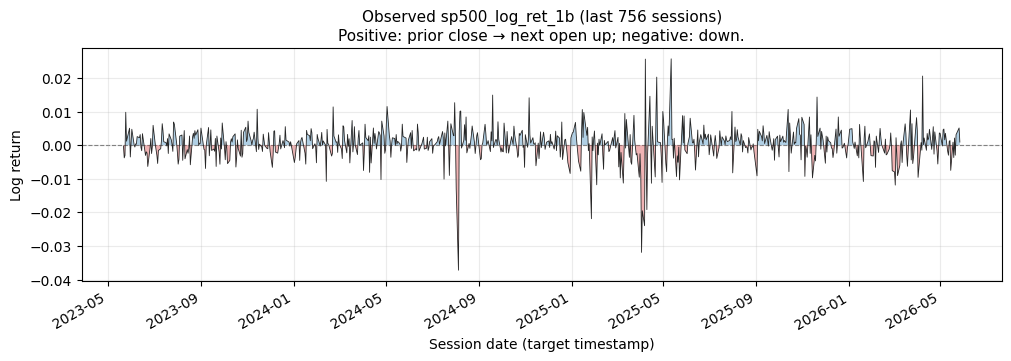

In [4]:
fig, _ = plot_sp500_log_return_recent(svc_no_cov, n_trading_days=756)
plt.show()

---
## 6. Task and backtest window

The evaluation window comes from the YAML **`backtest`** block (loaded into
`spec` below). Printing `describe_spec` keeps the notebook self-documenting
(same spirit as the Canada food CPI experiment).



In [5]:
spec = BacktestSpec.model_validate(EXPERIMENT_CFG["backtest"])
print(describe_spec(spec, data_service=svc_cov))

BacktestSpec
  description: Smoke multivariate demo; forecast origins are business days in [start, end].
  start:       2020-03-01 00:00:00
  end:         2020-04-08 00:00:00
  stride:      1
  warmup:      60

Task: sp500_log_return_1b
  description: Forecast next-session open vs prior close S&P500 log return.
  horizons:    1
  frequency:   B
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: sp500_log_ret_1b
    description:    S&P 500 log return from prior session adjusted close to current session open (Yahoo Finance ^GSPC)
    source:         Yahoo Finance (^GSPC), derived
    units:          log-return
    frequency:      B


---
## 7. Backtests — one row per enabled model (`backtest_grid.py`)

Each `true` entry under ``experiment.run_models`` in the YAML (loaded as
``RUN_MODELS``) runs a full `backtest` (one fit per origin).
`mean_crps` is CRPS on the **log-return** target; `mean_crps_open` is CRPS on the
**realised open price (USD)** using the same quantile fan mapped through
`prior_adj_close * exp(q)`.

The table below is sorted by **mean CRPS (log)** (lower is better).



In [6]:
RESULTS_DF = run_multivariate_backtest_grid(
    run_models=RUN_MODELS,
    spec=spec,
    selected_covariates=selected_covariates,
    svc_no_cov=svc_no_cov,
    svc_cov=svc_cov,
    price_df=SP500_PRICE_DF,
    lags=LAGS,
    lags_past_covariates=LAGS_PAST_COVARIATES,
    num_samples=NUM_SAMPLES,
    lightgbm_kwargs=LIGHTGBM_KWARGS,
)

---
## 8. Open price — point forecast vs realised

For **each** enabled model (in order: ``linreg_with_covariates``,
``lightgbm_with_covariates``, then ``linreg_target_only``, …), the cell runs the
same single-run backtest wiring as the leaderboard. Successful runs are drawn
**together** on one axes (actual open once; one forecast line and light fan per
model). Some macro covariates are not strictly on a business-day (``B``)
calendar; Darts can then raise when building past covariates — those runs are
**skipped** with a printed reason; remaining models still appear on the chart.

Each curve maps the **median** log-return forecast to USD with
``prior_adj_close * exp(q)`` (same scaling as open-level CRPS). Light bands use
the **5th and 95th** log-return quantiles through the same mapping.


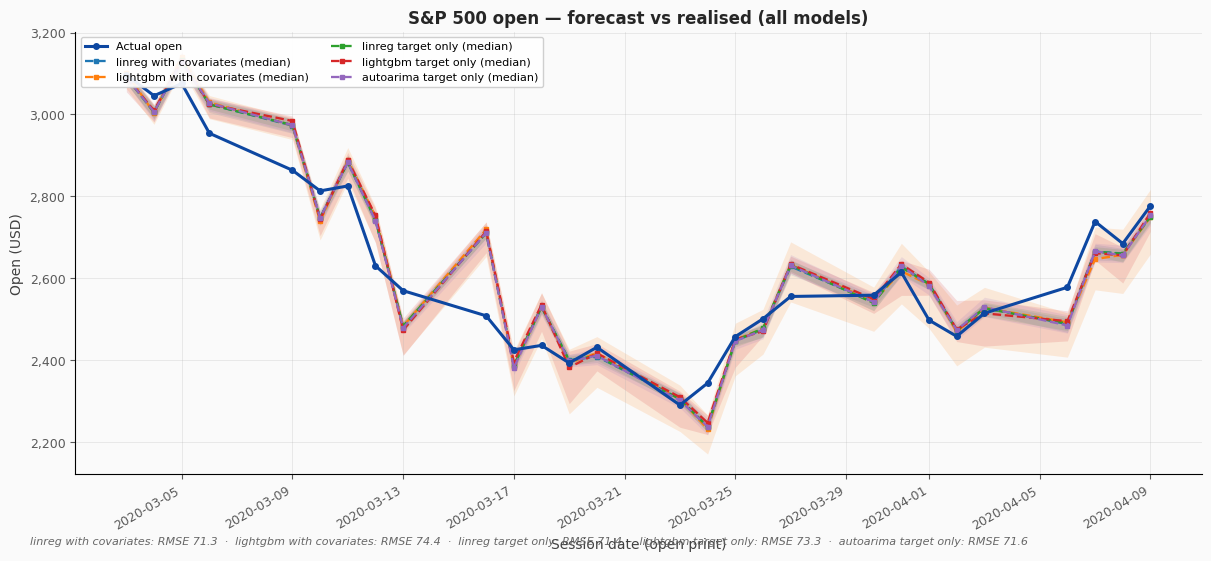

In [7]:
_open_demo_plan: list[str] = []
if RUN_MODELS.get("linreg_with_covariates"):
    _open_demo_plan.append("linreg_with_covariates")
if RUN_MODELS.get("lightgbm_with_covariates"):
    _open_demo_plan.append("lightgbm_with_covariates")
if RUN_MODELS.get("linreg_target_only"):
    _open_demo_plan.append("linreg_target_only")
if RUN_MODELS.get("lightgbm_target_only"):
    _open_demo_plan.append("lightgbm_target_only")
if RUN_MODELS.get("autoarima_target_only"):
    _open_demo_plan.append("autoarima_target_only")
_seen: set[str] = set()
_open_demo_plan = [k for k in _open_demo_plan if not (k in _seen or _seen.add(k))]

_open_ok: list[tuple[str, object]] = []
_open_fail_msgs: list[str] = []
for _k in _open_demo_plan:
    try:
        _open_bt = run_backtest_for_run_key(
            run_key=_k,
            spec=spec,
            selected_covariates=selected_covariates,
            svc_no_cov=svc_no_cov,
            svc_cov=svc_cov,
            lags=LAGS,
            lags_past_covariates=LAGS_PAST_COVARIATES,
            num_samples=NUM_SAMPLES,
            lightgbm_kwargs=LIGHTGBM_KWARGS,
        )
        _open_ok.append((_k, _open_bt))
    except ValueError as _exc:
        _open_fail_msgs.append(f"{_k}: {_exc}")
        continue

if _open_fail_msgs:
    print(
        "Open-price plots: skipped some runs (macro covariates are not always "
        "strictly business-day aligned for Darts). Details:\n" + "\n".join(_open_fail_msgs)
    )

if _open_ok:
    _open_by_run: dict[str, pd.DataFrame] = {}
    for _open_demo_key, _open_bt in _open_ok:
        _df = build_open_price_compare_frame(_open_bt.predictions, SP500_PRICE_DF)
        if not _df.empty:
            _open_by_run[_open_demo_key] = _df
    if _open_by_run:
        fig, _ = plot_open_forecast_vs_actual_multi(
            _open_by_run,
            title="S&P 500 open — forecast vs realised (all models)",
        )
        plt.show()
    else:
        print("Open-price compare frames empty — skip illustration.")
else:
    print("No enabled model completed — skip open-price illustration.")

---
## 9. Leaderboard — formatted table and CRPS charts (log vs open)


,run_key,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,mean_crps_open,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,error
3,lightgbm_with_covariates,lightgbm with covariates,True,9,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.01770,46.491,28,28,0,0.529,0.643,0.581,0.536,0.474,28,
2,lightgbm_target_only,lightgbm target only,False,0,—,darts_lightgbm,0.01834,48.365,28,28,0,0.526,0.714,0.606,0.536,0.439,28,
4,autoarima_target_only,autoarima target only,False,0,—,darts_autoarima,0.01897,49.901,28,28,0,0.400,0.286,0.333,0.429,0.378,28,
1,linreg_with_covariates,linreg with covariates,True,9,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,0.01952,51.389,28,28,0,0.500,0.929,0.650,0.500,0.551,28,
0,linreg_target_only,linreg target only,False,0,—,darts_linreg,0.01968,51.806,28,28,0,0.542,0.929,0.684,0.571,0.357,28,


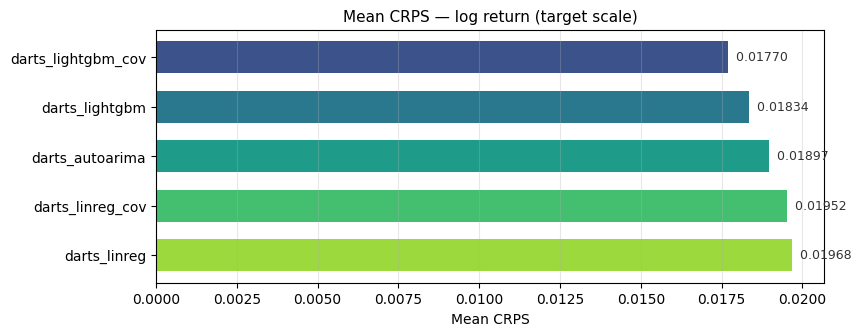

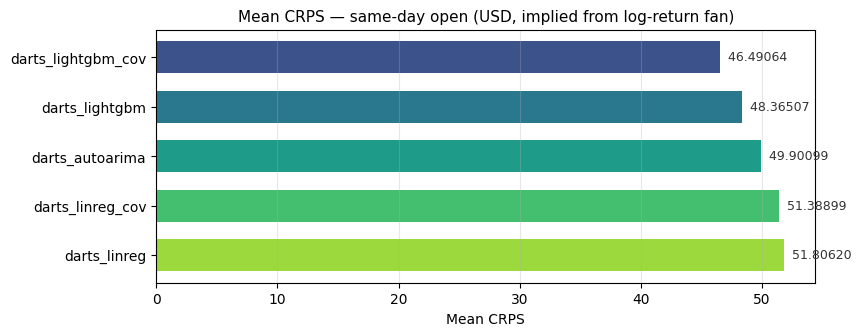

In [8]:
display_multivariate_backtest_leaderboard(RESULTS_DF)